# 11 - Overlay: ticker mentions vs price (AUTO, weekly)

Auto-picks the most-mentioned tickers in the window and overlays mentions vs
price. `FREQ='W'` = weekly (smoother); set `'D'` for daily or `'M'` for monthly.
The price line is forward-filled so it has no weekend gaps.

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
P = os.path.join(ROOT, 'data', 'processed')
PRICES_PATH = os.path.join(ROOT, 'data', 'prices', 'prices.parquet')

# window: the PIPELINE_* env vars (set by update_data.py, including its
# --start/--end overrides) win; otherwise fall back to the constants at the
# top of update_data.py. Same toggle as live vs backtest either way.
import update_data
START_DATE = os.environ.get('PIPELINE_START_DATE') or update_data.START_DATE
END_DATE = os.environ.get('PIPELINE_END_DATE')
if END_DATE is None:
    END_DATE = update_data.END_DATE
WIN_LO = pd.to_datetime(START_DATE)
WIN_HI = pd.to_datetime(END_DATE) if END_DATE else None
print('window:', WIN_LO.date(), '->', (WIN_HI.date() if WIN_HI is not None else 'LIVE (newest)'))

def clip_series(s):
    s = s[s.index >= WIN_LO]
    return s if WIN_HI is None else s[s.index <= WIN_HI]

def clip_dates(df, col):
    df = df[df[col] >= WIN_LO]
    return df if WIN_HI is None else df[df[col] <= WIN_HI]

def load_prices():
    if not os.path.exists(PRICES_PATH):
        raise FileNotFoundError('prices.parquet not found - run  python pull_bloomberg_prices.py  first.')
    px = pd.read_parquet(PRICES_PATH); px['date'] = pd.to_datetime(px['date'])
    return px

def price_series(prices, symbol):
    # daily close, then made CONTINUOUS (forward-fill weekends/holidays) so the
    # line is smooth with no gaps. Clip to the window.
    one = prices[prices['symbol'] == symbol].sort_values('date')
    s = one.set_index('date')['px_last']
    if not s.empty:
        s = s.asfreq('D').ffill()
    return clip_series(s)


# --- x-axis tick control (X_TICKS in the parameters cell) ---
# 'auto' = matplotlib decides; 'W' = a label every week; 'M' = every month.
# Weekly labels are only readable on windows up to ~6 months - use
# PLOT_LAST_DAYS to zoom in first.
import matplotlib.dates as mdates

def set_date_ticks(ax, ticks):
    if ticks == 'W':
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # Mondays
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
    elif ticks == 'M':
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

window: 2022-01-01 -> 2023-01-01


In [2]:
HOW_MANY = 6      # how many top tickers to plot
FREQ = 'W'        # 'W' weekly (smooth), 'D' daily, 'M' monthly
ROLL = 7          # daily smoothing (only used when FREQ='D')
X_TICKS = 'auto'  # x-axis labels: 'auto', 'W' (weekly), 'M' (monthly)
PLOT_LAST_DAYS = None   # e.g. 120 = zoom to the last 120 days (None = whole window)
NORMALISE = True  # True = plot SHARE of that day's total mentions (%), not raw
                  # counts. Raw counts jump at the archive->live boundary because
                  # the archive held millions of posts/day and the live fetch
                  # collects hundreds - share-of-chatter is comparable across eras.
MIN_TOTAL = 30    # mask days with fewer total mentions than this (too noisy)

top names MISSING from prices.parquet (re-run pull_bloomberg_prices.py): ['BTC', 'ETH']
auto tickers (top mentioned WITH price data): ['BBBY', 'TSLA', 'AAPL', 'AMZN', 'SPY', 'SCHD']


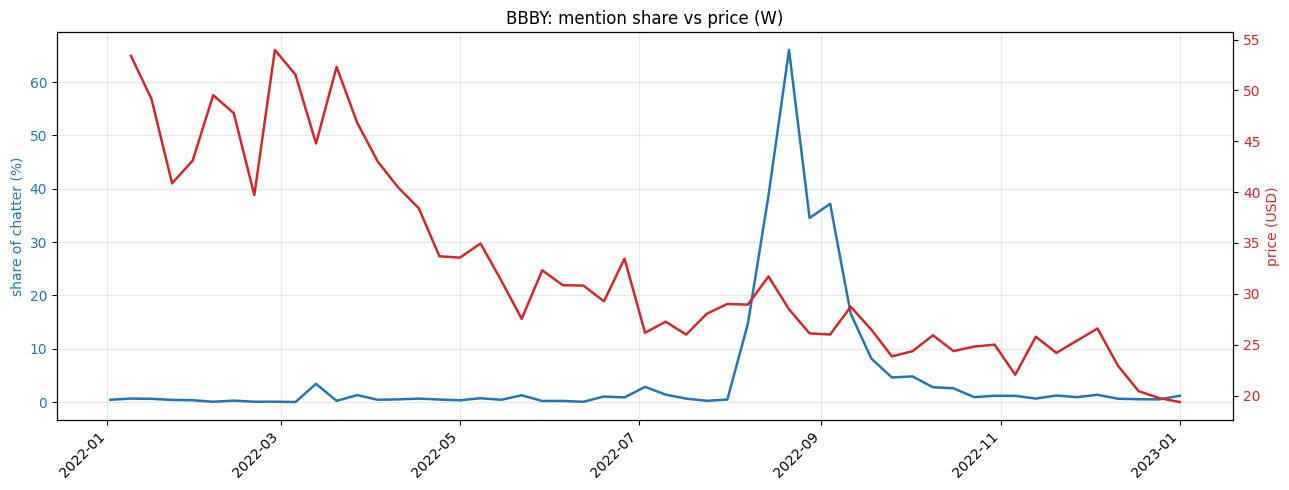

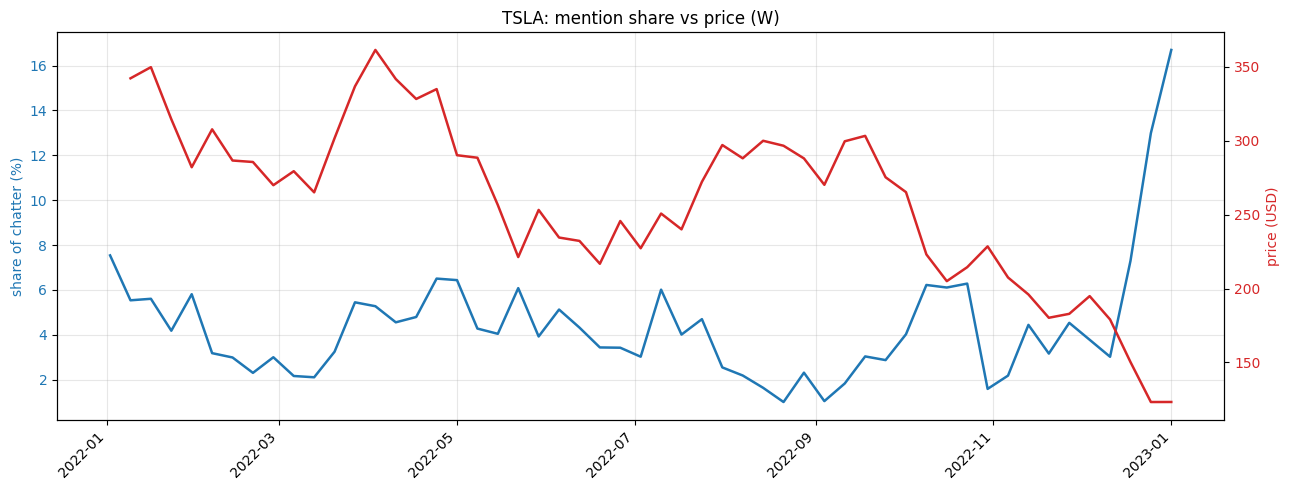

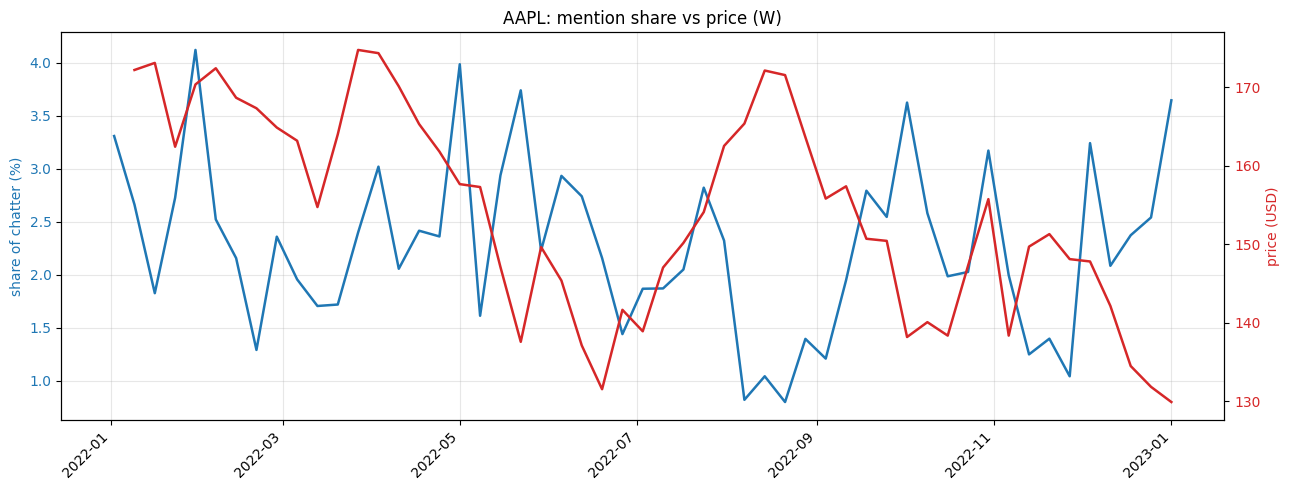

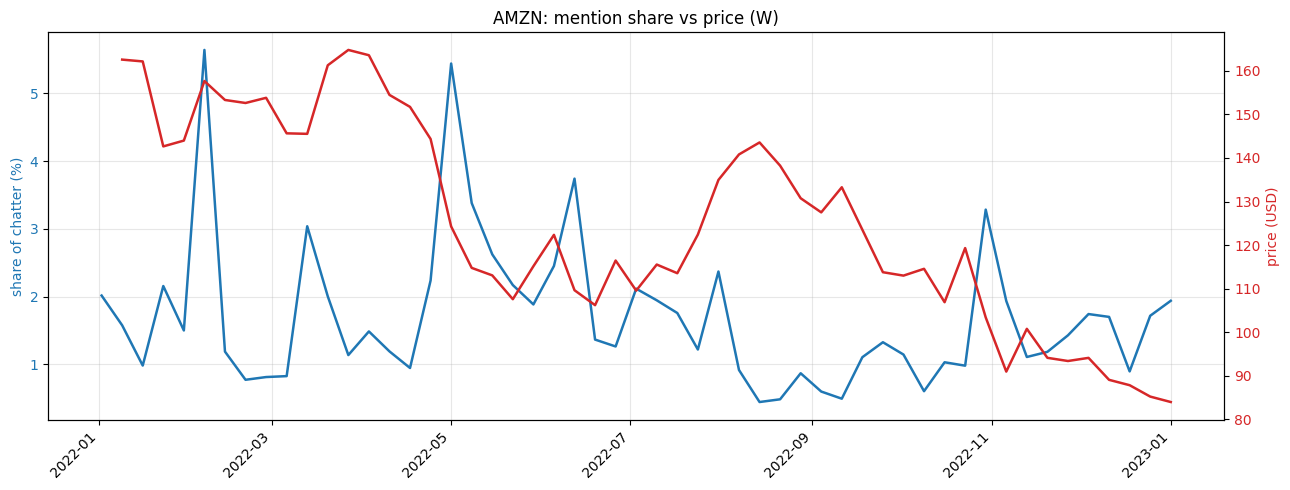

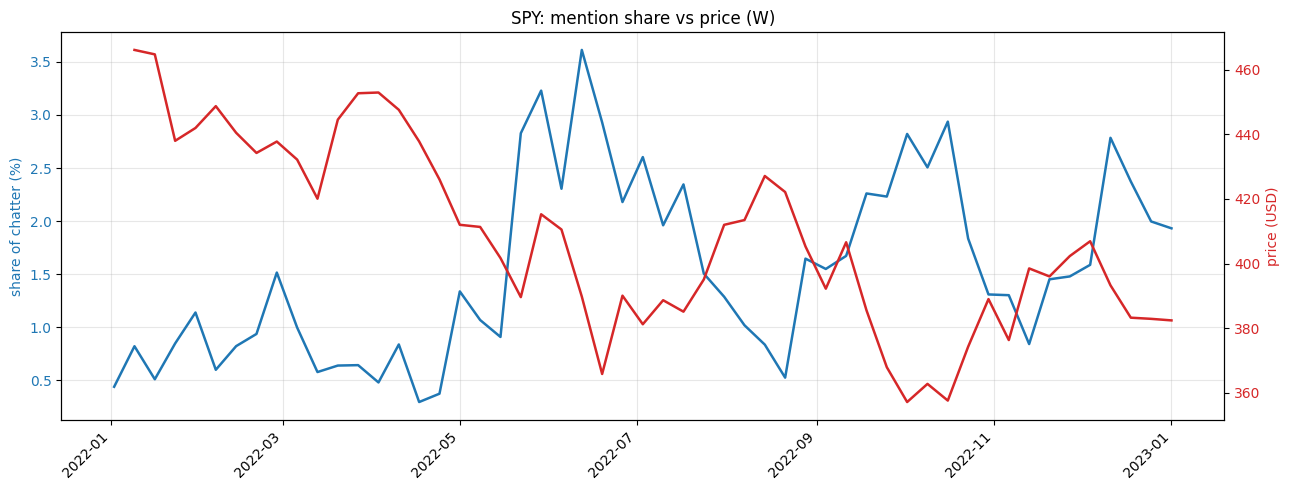

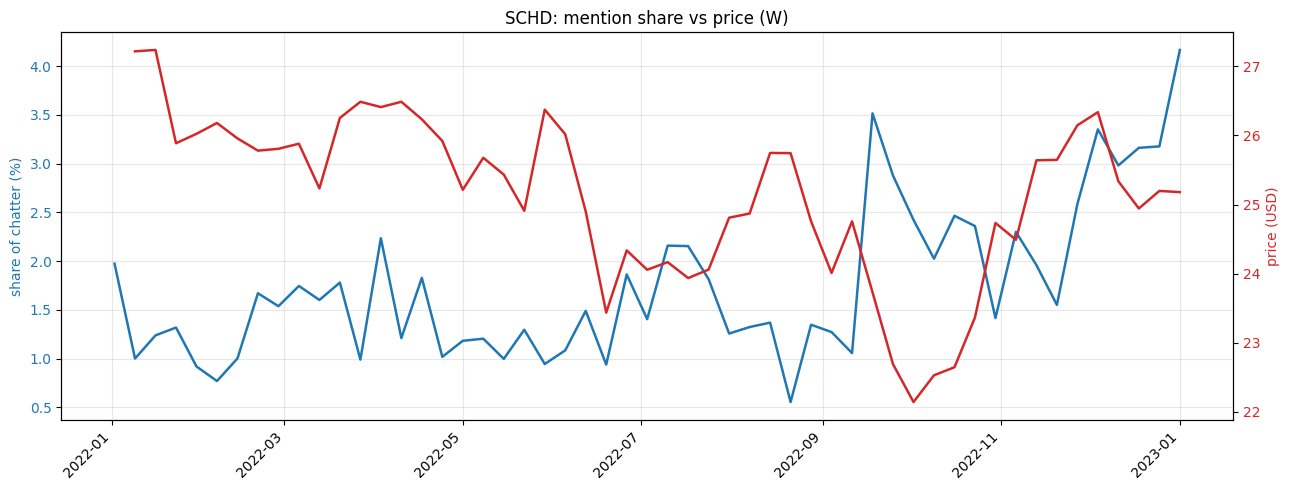

In [3]:
counts = pd.read_parquet(os.path.join(P, 'daily_ticker_counts.parquet'))
counts['date'] = pd.to_datetime(counts['date']); counts = clip_dates(counts, 'date')
if PLOT_LAST_DAYS:                       # zoom: only the most recent stretch
    WIN_LO = max(WIN_LO, counts['date'].max() - pd.Timedelta(days=PLOT_LAST_DAYS))
    counts = counts[counts['date'] >= WIN_LO]
# total mentions per day - used for the share normalisation and the noise mask
if counts.empty:
    print('!' * 72)
    print(f'NO AGGREGATE DATA in this window ({START_DATE} -> {END_DATE or "today"}).')
    print('The aggregates only span what was last built. Fix: run')
    print("  python update_data.py --full   (builds them over ALL history once),")
    print('then any window works. See the WINDOW CHECK in the run log for which')
    print('sources cover which dates.')
    print('!' * 72)
day_totals = counts.groupby('date')['mention_count'].sum()
prices = load_prices()
priced = set(prices['symbol'].unique())
ranked = counts.groupby('ticker')['mention_count'].sum().sort_values(ascending=False)
unpriced = [t for t in ranked.head(HOW_MANY).index if t not in priced]
if unpriced:
    print('top names MISSING from prices.parquet (re-run pull_bloomberg_prices.py):', unpriced)
tickers = [t for t in ranked.index if t in priced][:HOW_MANY]
print('auto tickers (top mentioned WITH price data):', tickers)
for ticker in tickers:
    m = counts[counts['ticker'] == ticker].sort_values('date').set_index('date')['mention_count'].asfreq('D').fillna(0)
    if NORMALISE:
        # share of that day's total chatter, in % - comparable across eras
        # however much raw data each era has. Low-volume days are masked
        # (a 1-post day would otherwise read as a fake 100% spike).
        totals = day_totals.reindex(m.index).fillna(0)
        # keep everything float64: where() puts NaN where totals is zero,
        # so no pd.NA ever enters the series (rolling/resample need floats)
        totals = totals.astype('float64')
        m = (m.astype('float64') / totals.where(totals > 0)) * 100
        m[totals < MIN_TOTAL] = float('nan')
    px = price_series(prices, ticker)
    if px.empty:
        print('skip', ticker, '- no price rows'); continue
    if not px.empty:
        line_end = (WIN_HI if WIN_HI is not None else m.index.max())
        if (line_end - px.index.max()).days > 7:
            print('note', ticker, f'- price data ENDS {px.index.max().date()} '
                  '(delisted or no later prices) - plotting what exists')

    if FREQ == 'D':
        if ROLL > 1: m = m.rolling(ROLL, min_periods=1).mean()
    else:
        m = m.resample(FREQ).mean() if NORMALISE else m.resample(FREQ).sum()
        px = px.resample(FREQ).last()
    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.plot(m.index, m.values, color='tab:blue', linewidth=1.8, label='mentions')
    ax1.set_ylabel(('share of chatter (%)' if NORMALISE else f'mentions per {FREQ}'), color='tab:blue'); ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax1.twinx(); ax2.plot(px.index, px.values, color='tab:red', linewidth=1.8, label='price')
    ax2.set_ylabel('price (USD)', color='tab:red'); ax2.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_title(f"{ticker}: {'mention share' if NORMALISE else 'mentions'} vs price ({FREQ})"); ax1.grid(True, alpha=0.3)
    set_date_ticks(ax1, X_TICKS)
    fig.tight_layout(); plt.show()